In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

sns.set(style="whitegrid")
%matplotlib inline

In [3]:
df = pd.read_csv("train2.csv")
print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Null check
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
print(nulls)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [5]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

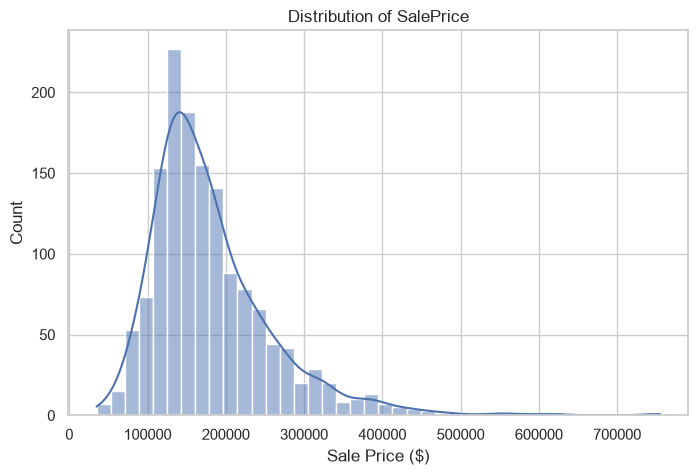

Skewness: 1.8828757597682129


In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df["SalePrice"], kde=True, bins=40)
plt.title("Distribution of SalePrice")
plt.xlabel("Sale Price ($)")
plt.show()

print("Skewness:", df["SalePrice"].skew())

In [7]:
#select features
features_num = [
    "LotArea", "OverallQual", "OverallCond", "YearBuilt", "YearRemodAdd",
    "TotalBsmtSF", "FullBath", "HalfBath", "BedroomAbvGr", "TotRmsAbvGrd",
    "GarageCars", "GrLivArea"
]
features_cat = ["Neighborhood"]
target = "SalePrice"

data = df[features_num + features_cat + [target]].copy()
data.head()

,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,TotalBsmtSF,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,GarageCars,GrLivArea,Neighborhood,SalePrice
0,8450,7,5,2003,2003,856,2,1,3,8,2,1710,CollgCr,208500
1,9600,6,8,1976,1976,1262,2,0,3,6,2,1262,Veenker,181500
2,11250,7,5,2001,2002,920,2,1,3,6,2,1786,CollgCr,223500
3,9550,7,5,1915,1970,756,1,0,3,7,3,1717,Crawfor,140000
4,14260,8,5,2000,2000,1145,2,1,4,9,3,2198,NoRidge,250000


In [8]:
#Handling missing values
print(data.isnull().sum())

LotArea         0
OverallQual     0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
TotalBsmtSF     0
FullBath        0
HalfBath        0
BedroomAbvGr    0
TotRmsAbvGrd    0
GarageCars      0
GrLivArea       0
Neighborhood    0
SalePrice       0
dtype: int64


In [9]:
data["GarageCars"] = data["GarageCars"].fillna(0)
data["TotalBsmtSF"] = data["TotalBsmtSF"].fillna(0)

data["HouseAge"] = df["YrSold"] - data["YearBuilt"]
data["YearsSinceRemod"] = df["YrSold"] - data["YearRemodAdd"]
data = data.drop(columns=["YearBuilt", "YearRemodAdd"])

print(data.isnull().sum().sum(), "missing values remain")

0 missing values remain


In [10]:
data_encoded = pd.get_dummies(data, columns=["Neighborhood"], drop_first=True)
print(data_encoded.shape)
data_encoded.head()

(1460, 37)


,LotArea,OverallQual,OverallCond,TotalBsmtSF,FullBath,HalfBath,BedroomAbvGr,TotRmsAbvGrd,GarageCars,GrLivArea,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,8450,7,5,856,2,1,3,8,2,1710,...,False,False,False,False,False,False,False,False,False,False
1,9600,6,8,1262,2,0,3,6,2,1262,...,False,False,False,False,False,False,False,False,False,True
2,11250,7,5,920,2,1,3,6,2,1786,...,False,False,False,False,False,False,False,False,False,False
3,9550,7,5,756,1,0,3,7,3,1717,...,False,False,False,False,False,False,False,False,False,False
4,14260,8,5,1145,2,1,4,9,3,2198,...,True,False,False,False,False,False,False,False,False,False


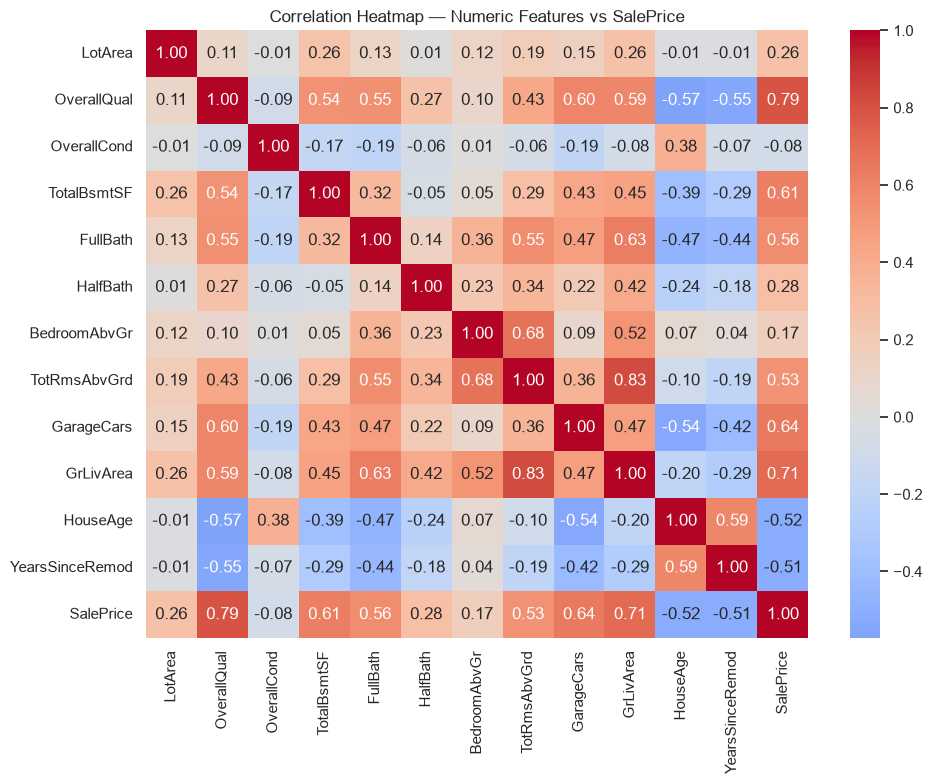

In [11]:
#Correlation heatmap
numeric_cols = features_num + ["HouseAge", "YearsSinceRemod", target]
corr = data_encoded[[c for c in numeric_cols if c in data_encoded.columns]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Numeric Features vs SalePrice")
plt.tight_layout()
plt.show()

In [12]:
corr["SalePrice"].sort_values(ascending=False)

SalePrice          1.000000
OverallQual        0.790982
GrLivArea          0.708624
GarageCars         0.640409
TotalBsmtSF        0.613581
FullBath           0.560664
TotRmsAbvGrd       0.533723
HalfBath           0.284108
LotArea            0.263843
BedroomAbvGr       0.168213
OverallCond       -0.077856
YearsSinceRemod   -0.509079
HouseAge          -0.523350
Name: SalePrice, dtype: float64

In [13]:
#Train/test split (80/20)

In [14]:
X = data_encoded.drop(columns=["SalePrice"])
y = data_encoded["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1168, 36)
Test shape: (292, 36)


In [15]:
#Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [16]:
#Evaluate: MSE, RMSE, R²
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2:   {r2:.4f}")

MSE:  1,200,202,084.09
RMSE: 34,643.93
R2:   0.8435


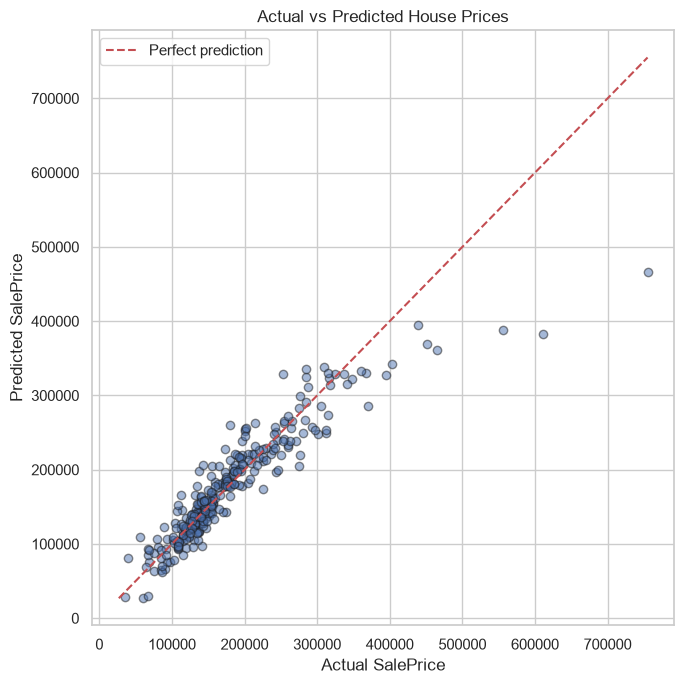

In [17]:
#Scatter plot: actual vs predicted
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolor="k")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.tight_layout()
plt.show()

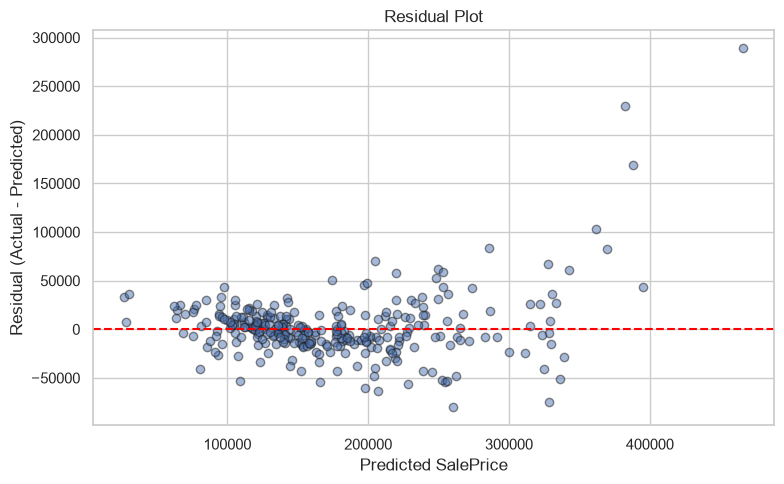

In [18]:
#Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5, edgecolor="k")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

In [19]:
#Coefficient analysis
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lr.coef_
}).sort_values("coefficient", ascending=False)

print("Top 10 positive impact on price:")
print(coef_df.head(10))

print("\nTop 10 negative impact on price:")
print(coef_df.tail(10))

Top 10 positive impact on price:
                 feature   coefficient
33  Neighborhood_StoneBr  77609.759021
26  Neighborhood_NoRidge  74508.642708
27  Neighborhood_NridgHt  72492.011397
35  Neighborhood_Veenker  55192.424840
17  Neighborhood_Crawfor  44836.526137
15  Neighborhood_ClearCr  39097.251961
34   Neighborhood_Timber  32632.772316
32  Neighborhood_Somerst  32344.779894
14  Neighborhood_BrkSide  28598.895413
16  Neighborhood_CollgCr  24632.927178

Top 10 negative impact on price:
                 feature   coefficient
5               HalfBath    968.809147
9              GrLivArea     41.542078
3            TotalBsmtSF     19.438897
0                LotArea      0.567893
11       YearsSinceRemod   -117.097712
10              HouseAge   -384.844455
4               FullBath   -937.458153
13   Neighborhood_BrDale  -6571.345583
6           BedroomAbvGr  -7421.160006
12  Neighborhood_Blueste -10956.312449


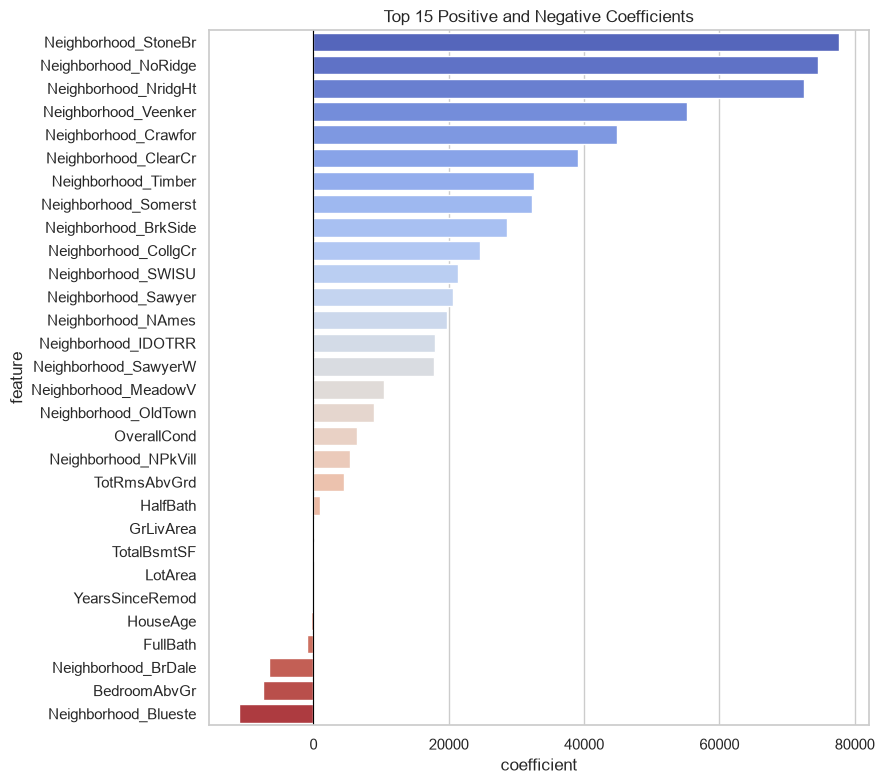

In [21]:
top_n = 15
plot_df = pd.concat([coef_df.head(top_n), coef_df.tail(top_n)])

plt.figure(figsize=(9, 8))
sns.barplot(data=plot_df, x="coefficient", y="feature", hue="feature", palette="coolwarm", legend=False)
plt.title(f"Top {top_n} Positive and Negative Coefficients")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

In [22]:
#Ridge and Lasso comparison
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

lasso = Lasso(alpha=1000, max_iter=10000)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

def report(name, y_true, y_hat):
    mse_ = mean_squared_error(y_true, y_hat)
    return {
        "Model": name,
        "MSE": mse_,
        "RMSE": np.sqrt(mse_),
        "R2": r2_score(y_true, y_hat)
    }

results = pd.DataFrame([
    report("Linear Regression", y_test, y_pred),
    report("Ridge (alpha=1.0)", y_test, y_pred_ridge),
    report("Lasso (alpha=1000)", y_test, y_pred_lasso),
])
results

,Model,MSE,RMSE,R2
0,Linear Regression,1.200202e+09,34643.932861,0.843527
1,Ridge (alpha=1.0),1.197756e+09,34608.618348,0.843845
2,Lasso (alpha=1000),1.408042e+09,37523.886425,0.816430
